In [1]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px 
import seaborn as sns
import plotly.graph_objects as go
import os 
from dotenv import load_dotenv

load_dotenv(override=True)


True

In [2]:
#extraer los datos de mySQL y crear un DataFrame de pandas
def extract_data_from_mysql(query):
    """
    Extrae los datos de una consulta SQL y los devuelve en un DataFrame.

    Parámetros:
    query (str): Consulta SQL que se ejecutará sobre la base de datos.

    Retorna:
    pd.DataFrame: DataFrame con los resultados obtenidos de la consulta.
    """

   
    # Configuración de la conexión a la base de datos
    config = {
        'user':     os.getenv('MYSQL_USER'),
        'password': os.getenv('MYSQL_PASSWORD'),
        'host':     os.getenv('MYSQL_HOST'),
        'database': os.getenv('MYSQL_DATABASE'),
    }

    # Establecer la conexión
    conn = mysql.connector.connect(**config)

    # Crear DataFrame
    df_emisiones = pd.read_sql(query, conn)

    # Cerrar la conexión
    conn.close()
    return df_emisiones
  



In [3]:
datos=extract_data_from_mysql('''SELECT
       area, producto, anio,
    SUM(CASE WHEN codigo_elemento = 72441 THEN valor END) AS ch4,
    SUM(CASE WHEN codigo_elemento = 72431 THEN valor END) AS n2o,
    SUM(CASE WHEN codigo_elemento = 5111  THEN valor END) AS cabezas,
    SUM(CASE WHEN codigo_elemento = 72441 THEN valor * 28
             WHEN codigo_elemento = 72431 THEN valor * 265 END) AS co2eq
FROM dataset_fao
WHERE codigo_elemento IN (5111, 72441, 72431)
GROUP BY area, producto, anio;''')

cols = ['ch4', 'n2o', 'cabezas', 'co2eq']
datos[cols]= datos[cols].astype(float)

C:\Users\UsuarioM.XTALENTO104\AppData\Local\Temp\ipykernel_15000\947286608.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emisiones = pd.read_sql(query, conn)


¿Qué es CO2eq?
El dióxido de carbono equivalente se expresa como una combinación lineal de las masas emitidas de metano (CH4) y óxido nitroso (NO2), utilizando como coeficientes sus respectivos Potenciales de Calentamiento Global (GWP), que son 28 para el CH4 y 265 para el N20

CO2 = 28*CH4 + 265*N20

# 1. ¿Cuánto emite la ganadería y hacia dónde va?
Esta primera vista agrega todas las emisiones mundiales del sector ganadero —metano y óxido nitroso, todos los animales y todos los continentes— en una sola serie temporal.

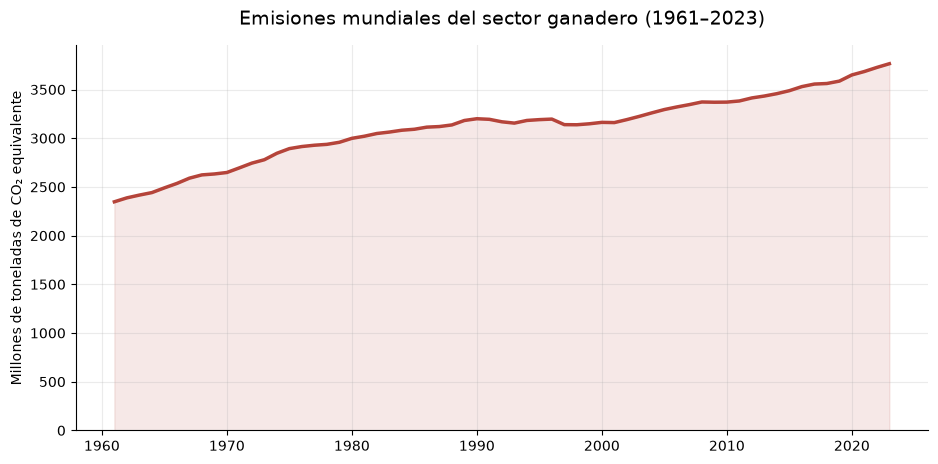

1961: 2,347 Mt
2023: 3,765 Mt
Crecimiento: ×1.60


In [4]:
serie = datos.groupby('anio')['co2eq'].sum() / 1000   # a millones de toneladas

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(serie.index, serie.values, linewidth=2.5, color='#b5443a')
ax.fill_between(serie.index, serie.values, alpha=0.12, color='#b5443a')

ax.set_title('Emisiones mundiales del sector ganadero (1961–2023)', fontsize=14, pad=15)
ax.set_ylabel('Millones de toneladas de CO₂ equivalente')
ax.set_ylim(0, None)
ax.grid(alpha=0.25)
ax.spines[['top','right']].set_visible(False)
plt.show()

print(f"1961: {serie.loc[1961]:,.0f} Mt")
print(f"2023: {serie.loc[2023]:,.0f} Mt")
print(f"Crecimiento: ×{serie.loc[2023]/serie.loc[1961]:.2f}")


Las emisiones ganaderas mundiales pasaron de 2.347 a 3.765 millones de toneladas de CO₂ equivalente entre 1961 y 2023: un crecimiento del 60% en seis décadas. El máximo de toda la serie es el último año registrado, lo que indica que la tendencia no ha alcanzado techo.
La curva no es uniforme. Se observa un estancamiento durante los años noventa, seguido de una reanudación del crecimiento a partir del año 2000. Esto se debe a la disolución de la Unión Soviética en 1991, que provocó una reducción significativa del censo ganadero en Europa del Este y Asia Central, y a una reforma de la Política Agraria común europea en 1992. 

# 2. ¿Qué animales están detrás de esas emisiones?

El total mundial esconde diferencias enormes entre especies. Vamos a mirarlo de dos formas: primero cuánto emite cada tipo de ganado en conjunto, y después cuánto emite cada animal individual. La comparación entre ambas vistas es la clave del análisis.

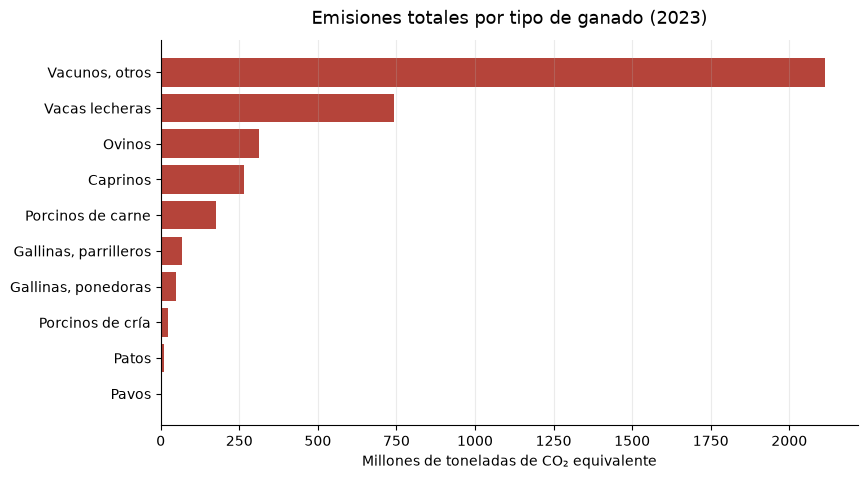

In [5]:
ult = datos[datos['anio'] == 2023].groupby('producto')[['co2eq','cabezas']].sum()
ult = ult.sort_values('co2eq')

fig, ax = plt.subplots(figsize=(9,5))
ax.barh(ult.index, ult['co2eq']/1000, color='#b5443a')
ax.set_title('Emisiones totales por tipo de ganado (2023)', fontsize=13, pad=12)
ax.set_xlabel('Millones de toneladas de CO₂ equivalente')
ax.grid(axis='x', alpha=0.25)
ax.spines[['top','right']].set_visible(False)
plt.show()


Los vacunos de carne (2.114 Mt) y las vacas lecheras (741 Mt) suman el 76% de todas las emisiones ganaderas mundiales. Los pollos, siendo con diferencia los más numerosos, apenas aparecen.

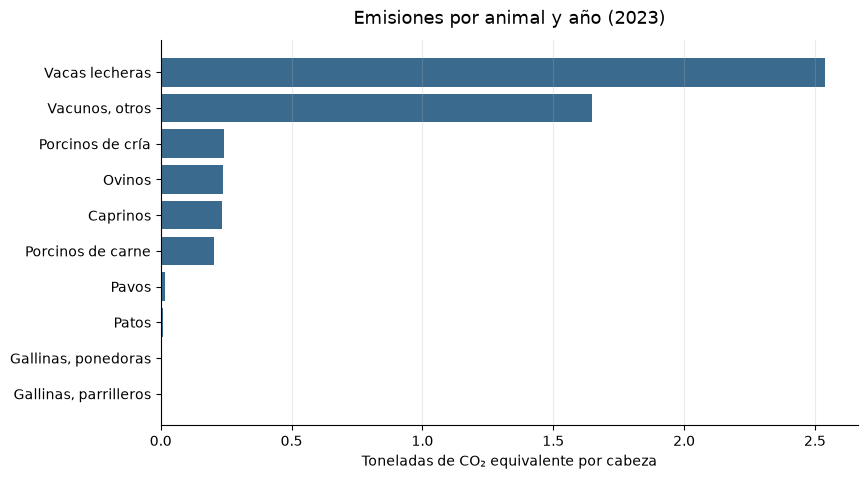

In [6]:
ult['por_cabeza'] = ult['co2eq'] * 1000 / ult['cabezas']
pc = ult['por_cabeza'].sort_values()

fig, ax = plt.subplots(figsize=(9,5))
ax.barh(pc.index, pc.values, color='#3a6b8f')

# Escala lineal (por defecto)
ax.set_title('Emisiones por animal y año (2023)', fontsize=13, pad=12)
ax.set_xlabel('Toneladas de CO₂ equivalente por cabeza')
ax.grid(axis='x', alpha=0.25)
ax.spines[['top','right']].set_visible(False)

plt.show()

En este gráfico las aves prácticamente desaparecen, pero esto se debe a que el rango de valores en el eje X es tan amplio que los últimos valores no se ven, aunque existan. Para solventarlo hacemos un cambio de escala a escala logarítmica. A esta escala las aves no se ven. 

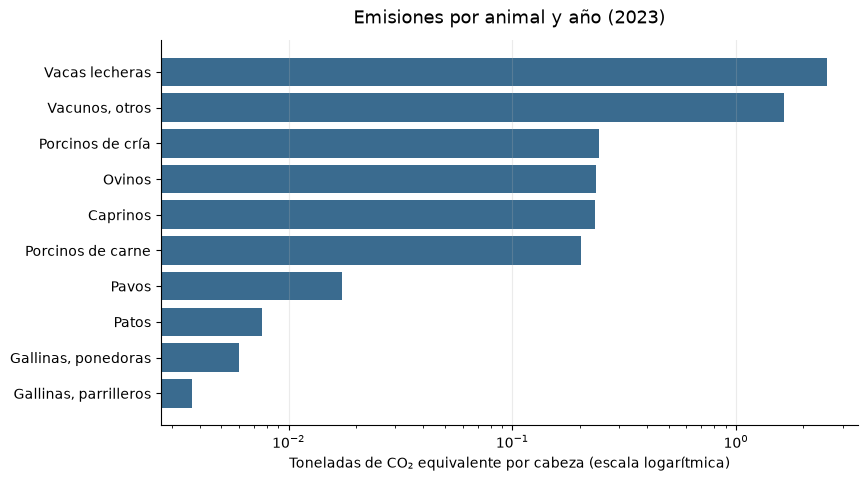

In [7]:
ult['por_cabeza'] = ult['co2eq'] * 1000 / ult['cabezas']
pc = ult['por_cabeza'].sort_values()

fig, ax = plt.subplots(figsize=(9,5))
ax.barh(pc.index, pc.values, color='#3a6b8f')
ax.set_xscale('log')
ax.set_title('Emisiones por animal y año (2023)', fontsize=13, pad=12)
ax.set_xlabel('Toneladas de CO₂ equivalente por cabeza (escala logarítmica)')
ax.grid(axis='x', alpha=0.25)
ax.spines[['top','right']].set_visible(False)
plt.show()

Sobre la escala logarítmica: cada paso del eje multiplica por diez, no suma.

Las dos vistas juntas revelan lo esencial: una vaca lechera emite tanto como 680 pollos parrilleros. Los rumiantes —vacuno, ovino, caprino— concentran el impacto porque su digestión produce metano, algo que no ocurre en cerdos ni aves.

Esto significa que las emisiones del sector no dependen tanto de cuántos animales se crían como de qué animales se crían. Es decir, reducir el consumo de vacuno tiene un efecto desproporcionadamente mayor que cualquier cambio en la avicultura.

# 3. ¿Ha crecido todo por igual?

Si las emisiones dependieran simplemente del número de animales, ambas magnitudes (número de animales y emisiones) deberían haber crecido a la vez. Comparamos su evolución partiendo de una base común en 1961.

In [8]:
anual = datos.groupby('anio').agg(co2eq=('co2eq','sum'), cabezas=('cabezas','sum'))
idx = anual / anual.iloc[0] * 100

fig = go.Figure()
fig.add_trace(go.Scatter(x=idx.index, y=idx['cabezas'], name='Número de animales',
                         line=dict(color='#3a6b8f', width=3),
                         hovertemplate='%{x}<br>Animales: %{y:.0f}<extra></extra>'))
fig.add_trace(go.Scatter(x=idx.index, y=idx['co2eq'], name='Emisiones',
                         line=dict(color='#b5443a', width=3),
                         hovertemplate='%{x}<br>Emisiones: %{y:.0f}<extra></extra>'))

fig.add_hline(y=100, line_dash='dot', line_color='grey')
fig.update_layout(
    title='Animales frente a emisiones (1961 = 100)',
    yaxis_title='Índice, base 100 en 1961',
    hovermode='x unified',
    template='plotly_white', height=500)
fig.show()


fig.write_html('bloque3_comparativa.html', include_plotlyjs='cdn')

En 2023 los animales están en 474 y las emisiones en 160. De 7.000 a 33.200 millones de cabezas, pero las emisiones solo x1,6
El número de animales desde 1961 hasta el año 2023 se ha multiplicado por 4,74. Sin embargo, las emisiones se han multiplicado solo por 1,6

In [9]:
comp = datos.pivot_table(index='anio', columns='producto', values='cabezas', aggfunc='sum')
comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100

fig = px.area(comp_pct, title='Composición del censo ganadero mundial (%)',
              template='plotly_white',
              color_discrete_sequence=px.colors.qualitative.Prism)
fig.update_layout(yaxis_title='% del total de cabezas', xaxis_title='',
                  legend_title='', height=520)
fig.update_traces(hovertemplate='%{y:.1f}%<extra>%{fullData.name}</extra>')
fig.show()


fig.write_html('bloque3_composicion.html', include_plotlyjs='cdn') #guardar en HTML

Las aves pasan del 61,5% al 85% del censo mundial; los rumiantes caen del 32,7% al 12,1%. Los pollos parrilleros se multiplicaron por 9,4 y las vacas solo por 1,76.

Celda markdown — la interpretación

Los animales se multiplicaron por 4,7, pero las emisiones solo por 1,6. Esta divergencia podría interpretarse como una mejora de eficiencia del sector, pero la segunda gráfica muestra que la causa es otra: el crecimiento se concentró casi por completo en aves, que emiten cantidades marginales.

Dicho de otro modo, el sector no ha reducido el impacto de criar una vaca; lo que ha ocurrido es que ha añadido miles de millones de pollos. La cabaña de rumiantes, que sigue siendo la responsable de tres cuartas partes de las emisiones, creció apenas un 65% en el mismo periodo.

Es la confirmación independiente de la conclusión del bloque anterior: lo que determina las emisiones es la composición del censo, no su tamaño.

# 4. ¿Dónde se emite?

Hasta ahora hemos tratado el mundo como un único agregado. Al separar por continentes aparece un panorama mucho menos homogéneo: mientras unas regiones multiplican sus emisiones, otras las han reducido a la mitad.

In [10]:
cont = datos.pivot_table(index='anio', columns='area', values='co2eq', aggfunc='sum') / 1000

colores = {'Américas':'#b5443a', 'Asia':'#d98c3f', 'África':'#4f8c5a',
           'Europa':'#3a6b8f', 'Oceanía':'#8a6b9c'}

fig_continentes = go.Figure()
for area in cont.columns:
    fig_continentes.add_trace(go.Scatter(
        x=cont.index, y=cont[area], name=area,
        line=dict(width=3, color=colores.get(area)),
        hovertemplate='%{y:.0f} Mt<extra>'+area+'</extra>'))

fig_continentes.update_layout(
    title='Emisiones ganaderas por continente (1961–2023)',
    yaxis_title='Millones de toneladas de CO₂ equivalente',
    xaxis_title='', hovermode='x unified',
    template='plotly_white', height=520)
fig_continentes.show()

	1961	2023	
Américas	734	1.264	×1,7
Asia	522	1.154	×2,2
África	223	788	×3,5
Europa	731	417	−43%
Oceanía	137	142	estable

Europa alcanzó su máximo en 1984 con 908 Mt y hoy se sitúa un 54% por debajo. Es el único continente que ha revertido la tendencia. En términos de reparto mundial, Europa pasó del 31% al 11% del total, mientras África subió del 9,5% al 21%.

In [11]:
esp = datos[datos['anio'] == 2023].pivot_table(
    index='area', columns='producto', values='co2eq', aggfunc='sum')
esp_pct = esp.div(esp.sum(axis=1), axis=0) * 100

fig_heatmap = px.imshow(esp_pct.round(1), text_auto=True, aspect='auto',
                        color_continuous_scale='OrRd',
                        title='Peso de cada especie en las emisiones del continente (%, 2023)',
                        template='plotly_white')
fig_heatmap.update_layout(height=480, xaxis_title='', yaxis_title='',
                          coloraxis_showscale=False)
fig_heatmap.show()

Cada continente tiene un perfil de emisiones distinto. En Américas el vacuno de carne concentra el 79,8% del total continental, el grado de dependencia de una sola especie más alto de los cinco. En África los caprinos alcanzan el 15,6%, muy por encima de cualquier otra región, y el vacuno baja al 52,5%. Asia presenta el reparto más equilibrado, con ovino y caprino aportando en torno al 11% cada uno junto al vacuno.

El impacto ganadero no solo se distribuye de forma desigual en el territorio, sino que responde a estructuras productivas diferentes en cada región.

Conclusiones generales
Cada continente presenta un perfil de emisiones diferente, lo que refleja diferencias en su modelo de producción ganadera.
Los bovinos suelen concentrar el mayor porcentaje de emisiones en la mayoría de los continentes. Esto se debe a que producen grandes cantidades de metano por fermentación entérica y generan más emisiones por cabeza que otras especies.
Las aves de corral y los porcinos suelen representar porcentajes menores, aunque en algunos continentes con producción intensiva (como Europa o Asia) pueden tener un peso relativamente elevado.
Algunos continentes muestran una fuerte especialización, donde una o dos especies concentran la mayor parte de las emisiones, mientras que otros presentan una distribución más equilibrada.
Las diferencias entre continentes reflejan tanto el tamaño del censo ganadero como la composición de las especies predominantes, además de factores como el sistema de producción y los hábitos de consumo.
Si observas estos patrones...

Puedes comentarlos así:

Una fila dominada por un único color intenso → ese continente depende principalmente de una especie para sus emisiones ganaderas.
Varias celdas con intensidades similares → las emisiones están más repartidas entre distintas especies.
Una especie muy intensa en casi todos los continentes → esa especie constituye la principal fuente de emisiones ganaderas a escala mundial.
Una especie con valores altos solo en uno o dos continentes → indica una especialización regional de esa producción.
Interpretación para un TFG

Podrías escribir algo como:

El mapa de calor evidencia que la contribución relativa de cada especie a las emisiones ganaderas varía entre continentes. En términos generales, los bovinos concentran la mayor parte de las emisiones debido a la elevada producción de metano asociada a la fermentación entérica. Sin embargo, algunos continentes presentan una distribución más equilibrada entre especies, mientras que otros muestran una clara especialización, concentrando gran parte de sus emisiones en una única categoría ganadera. Estas diferencias reflejan las particularidades de los sistemas de producción y la estructura del sector ganadero en cada región.

Importante: como has normalizado por filas (esp.div(esp.sum(axis=1)) * 100), este gráfico no permite concluir qué continente contamina más, sino qué especies son responsables de las emisiones dentro de cada continente. Esa distinción conviene dejarla clara en la interpretación.




## 5. Conclusiones
Lo que muestran los datos

1. El impacto es grande y sigue creciendo. Las emisiones ganaderas mundiales pasaron de 2.347 a 3.765 Mt de CO₂ equivalente entre 1961 y 2023 (+60%). El máximo de la serie es el último año disponible: no hay señal de techo.

2. La responsabilidad está muy concentrada. Los rumiantes generan el 91,2% de las emisiones del sector, y solo el vacuno —carne y leche— el 75,8%. El origen es fisiológico: la fermentación entérica de su digestión produce metano, un gas 28 veces más potente que el CO₂.

3. La diferencia entre especies es de otro orden de magnitud. Una vaca lechera emite al año lo mismo que 680 pollos parrilleros (2,54 frente a 0,004 toneladas de CO₂eq). No es una diferencia de grado, es de naturaleza.

4. Por eso importa más la composición que el tamaño. El censo mundial se multiplicó por 4,7 y las emisiones solo por 1,6, porque el crecimiento fue casi íntegramente avícola: las aves pasaron del 61,5% al 85% del censo. La cabaña de rumiantes creció un 76%, y con ella las emisiones.

5. La distribución geográfica es muy desigual. África triplicó sus emisiones y Asia las duplicó, mientras Europa las redujo un 43% —aunque esa caída responde en buena medida al colapso de la cabaña soviética tras 1990, no a una política climática—. Cada continente presenta además un perfil productivo distinto.

Respuesta a la pregunta inicial

El vínculo entre alimentación y emisiones no es proporcional al volumen de ganado, sino a su composición. Las últimas seis décadas funcionan como un experimento natural: el mundo cuadruplicó su censo ganadero sin cuadruplicar sus emisiones, precisamente porque el crecimiento se orientó hacia especies de bajo impacto.

La implicación es directa. Con los ratios de 2023, reducir un 25% la cabaña de vacuno de carne evitaría unas 528 Mt de CO₂eq — más que las emisiones ganaderas de toda Europa (417 Mt), y cuatro veces más que lo que se ahorraría eliminando por completo la avicultura mundial (131 Mt). La palanca no está en producir menos carne, sino en producir y consumir otra carne.

Limitaciones del análisis
Los datos miden cabezas de ganado, no consumo. La conexión entre ambos es una inferencia razonable pero no está contenida en la fuente.
Las emisiones por cabeza se calculan sobre censo anual y no equivalen a emisiones por kilo de carne, que es la métrica estándar en estudios de huella alimentaria.
El conjunto cubre fermentación entérica y gestión de estiércol, pero no incluye el uso del suelo (deforestación asociada a pastos y cultivo de piensos), que en otras estimaciones representa una parte sustancial del impacto ganadero.
Una fracción de los valores figura como estimada (símbolo E) en la fuente original.
El escenario del párrafo anterior es un cálculo aritmético directo sobre los ratios actuales, no un modelo: no contempla sustitución de demanda ni efectos económicos de segundo orden.